In [9]:
import os
import urllib.request
import tarfile
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

if not os.path.exists('./data/facades'):
    os.makedirs('./data', exist_ok=True)
    urllib.request.urlretrieve("http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/facades.tar.gz", "./data/facades.tar.gz")
    with tarfile.open("./data/facades.tar.gz", "r:gz") as tar:
        tar.extractall(path="./data/")

class PairedImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        img = Image.open(img_path).convert("RGB")
        w, h = img.size

        img_B = img.crop((0, 0, w // 2, h))
        img_A = img.crop((w // 2, 0, w, h))

        if self.transform:
            img_A = self.transform(img_A)
            img_B = self.transform(img_B)

        return img_A, img_B

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = PairedImageDataset(root_dir='./data/facades/train', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)

test_dataset = PairedImageDataset(root_dir='./data/facades/val', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

/tmp/ipykernel_1488/3508117835.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="./data/")


In [10]:
class UNetDown(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True, dropout=0.0):
        super(UNetDown, self).__init__()
        layers = [nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2))
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

class UNetUp(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super(UNetUp, self).__init__()
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip_input):
        x = self.model(x)
        x = torch.cat((x, skip_input), 1)
        return x

class UNetGenerator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super(UNetGenerator, self).__init__()
        self.down1 = UNetDown(in_channels, 64, normalize=False)
        self.down2 = UNetDown(64, 128)
        self.down3 = UNetDown(128, 256)
        self.down4 = UNetDown(256, 512, dropout=0.5)
        self.down5 = UNetDown(512, 512, dropout=0.5)
        self.down6 = UNetDown(512, 512, dropout=0.5)
        self.down7 = UNetDown(512, 512, dropout=0.5)
        self.down8 = UNetDown(512, 512, normalize=False, dropout=0.5)

        self.up1 = UNetUp(512, 512, dropout=0.5)
        self.up2 = UNetUp(1024, 512, dropout=0.5)
        self.up3 = UNetUp(1024, 512, dropout=0.5)
        self.up4 = UNetUp(1024, 512, dropout=0.5)
        self.up5 = UNetUp(1024, 256)
        self.up6 = UNetUp(512, 128)
        self.up7 = UNetUp(256, 64)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)
        u1 = self.up1(d8, d7)
        u2 = self.up2(u1, d6)
        u3 = self.up3(u2, d5)
        u4 = self.up4(u3, d4)
        u5 = self.up5(u4, d3)
        u6 = self.up6(u5, d2)
        u7 = self.up7(u6, d1)
        return self.final(u7)

In [11]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self, in_channels=6):
        super(PatchGANDiscriminator, self).__init__()

        def discriminator_block(in_filters, out_filters, normalization=True):
            layers = [nn.Conv2d(in_filters, out_filters, kernel_size=4, stride=2, padding=1)]
            if normalization:
                layers.append(nn.BatchNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *discriminator_block(in_channels, 64, normalization=False),
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(512, 1, kernel_size=4, padding=1, bias=False)
        )

    def forward(self, img_A, img_B):
        img_input = torch.cat((img_A, img_B), 1)
        return self.model(img_input)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = UNetGenerator().to(device)
discriminator = PatchGANDiscriminator().to(device)

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_pixelwise = nn.L1Loss()
lambda_pixel = 100

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 10

for epoch in range(epochs):
    for i, (real_A, real_B) in enumerate(train_loader):
        real_A = real_A.to(device)
        real_B = real_B.to(device)

        valid = torch.ones((real_A.size(0), 1, 16, 16), device=device, requires_grad=False)
        fake = torch.zeros((real_A.size(0), 1, 16, 16), device=device, requires_grad=False)

        optimizer_G.zero_grad()
        fake_B = generator(real_A)
        pred_fake = discriminator(fake_B, real_A)

        loss_GAN = criterion_GAN(pred_fake, valid)
        loss_pixel = criterion_pixelwise(fake_B, real_B)
        loss_G = loss_GAN + lambda_pixel * loss_pixel

        loss_G.backward()
        optimizer_G.step()

        optimizer_D.zero_grad()
        pred_real = discriminator(real_B, real_A)
        loss_real = criterion_GAN(pred_real, valid)

        pred_fake_detach = discriminator(fake_B.detach(), real_A)
        loss_fake = criterion_GAN(pred_fake_detach, fake)

        loss_D = 0.5 * (loss_real + loss_fake)

        loss_D.backward()
        optimizer_D.step()

    print(f"[Epoch {epoch+1}/{epochs}] [D loss: {loss_D.item():.4f}] [G loss: {loss_G.item():.4f}]")

[Epoch 1/10] [D loss: 0.0480] [G loss: 47.3391]
[Epoch 2/10] [D loss: 0.0510] [G loss: 35.5865]
[Epoch 3/10] [D loss: 0.1304] [G loss: 41.2848]
[Epoch 4/10] [D loss: 0.2518] [G loss: 38.9642]
[Epoch 5/10] [D loss: 0.3018] [G loss: 29.7898]
[Epoch 6/10] [D loss: 0.1815] [G loss: 58.2710]
[Epoch 7/10] [D loss: 0.2475] [G loss: 40.1262]
[Epoch 8/10] [D loss: 1.2640] [G loss: 32.4407]
[Epoch 9/10] [D loss: 0.1054] [G loss: 35.5855]
[Epoch 10/10] [D loss: 0.0234] [G loss: 40.7121]


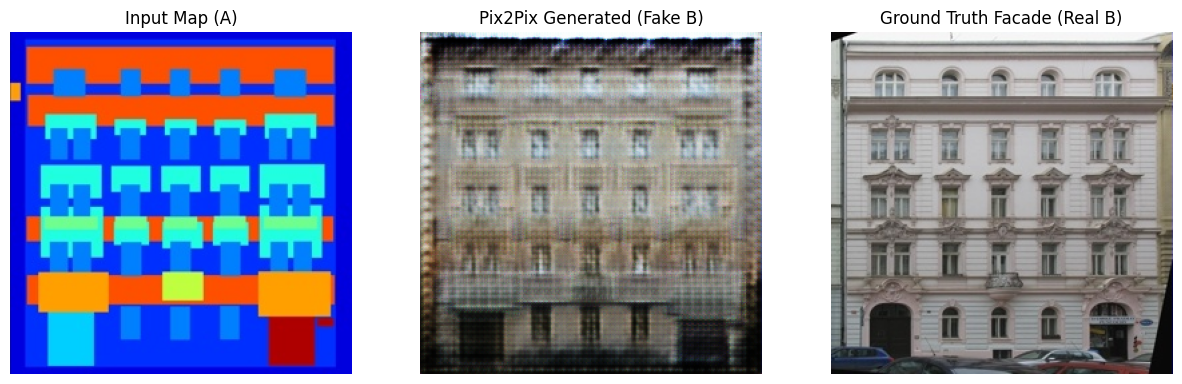

In [13]:
generator.eval()
dataiter = iter(test_loader)
real_A, real_B = next(dataiter)

real_A = real_A.to(device)
real_B = real_B.to(device)

with torch.no_grad():
    fake_B = generator(real_A)

real_A = real_A.cpu().squeeze() * 0.5 + 0.5
real_B = real_B.cpu().squeeze() * 0.5 + 0.5
fake_B = fake_B.cpu().squeeze() * 0.5 + 0.5

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(real_A.permute(1, 2, 0).numpy())
axes[0].set_title("Input Map (A)")
axes[0].axis('off')

axes[1].imshow(fake_B.permute(1, 2, 0).numpy())
axes[1].set_title("Pix2Pix Generated (Fake B)")
axes[1].axis('off')

axes[2].imshow(real_B.permute(1, 2, 0).numpy())
axes[2].set_title("Ground Truth Facade (Real B)")
axes[2].axis('off')

plt.show()